### Advertising and Sales


Data Fields:

TV -- amount spend on TV ads on sales in dollars.   
radio -- amount spend on radio ads on sales in dollars.   
newspaper -- amount spend on newspaper ads on sales in dollars.   
sales --- sale in dollars.

In [1]:
### Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge, SGDRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score


### Import data file

In [3]:
data = pd.read_csv('/content/Advertising.csv')

data.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


### Data Shape

In [4]:
data.shape

(200, 5)

### Check for Null values

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   radio       200 non-null    float64
 3   newspaper   200 non-null    float64
 4   sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


### Univariate Measures

In [6]:
data.describe()

,Unnamed: 0,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


### Visualize the Data

<Axes: xlabel='newspaper', ylabel='sales'>

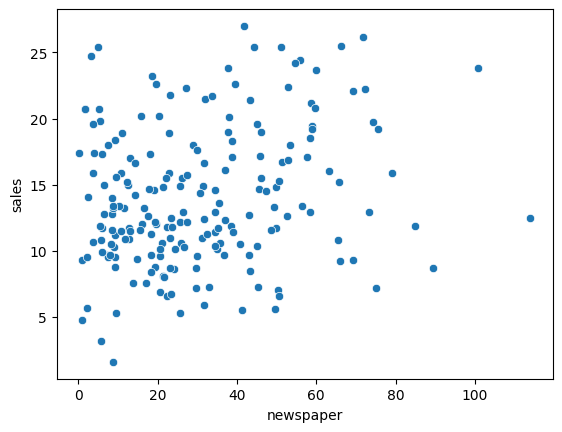

In [7]:
sns.scatterplot(data = data, x='newspaper', y = 'sales')

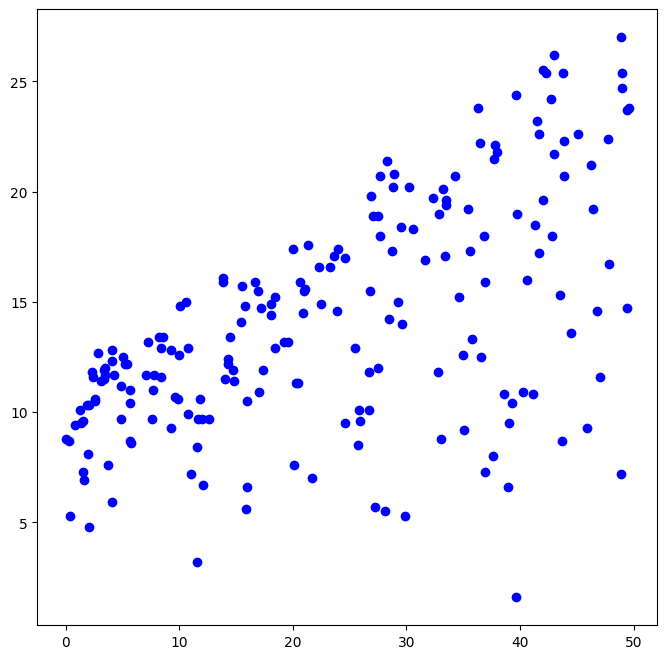

In [8]:

plt.figure(figsize=(8,8))

plt.scatter(data['radio'], data['sales'], c='b')

plt.show()

<Axes: xlabel='TV', ylabel='sales'>

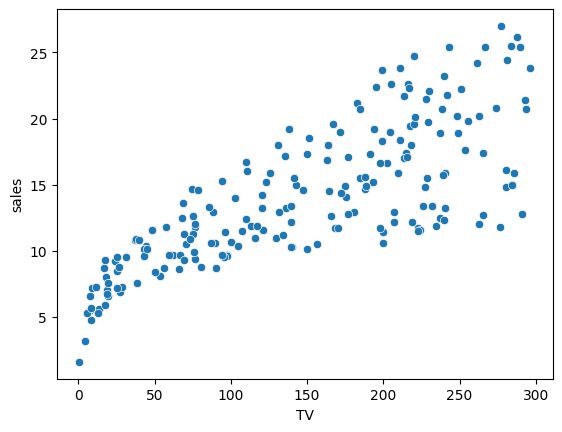

In [9]:
sns.scatterplot(data= data, x='TV', y = 'sales')

### Check for correlation

In [10]:
data_correlation = data.corr()
data_correlation

,Unnamed: 0,TV,radio,newspaper,sales
Unnamed: 0,1.000000,0.017715,-0.110680,-0.154944,-0.051616
TV,0.017715,1.000000,0.054809,0.056648,0.782224
radio,-0.110680,0.054809,1.000000,0.354104,0.576223
newspaper,-0.154944,0.056648,0.354104,1.000000,0.228299
sales,-0.051616,0.782224,0.576223,0.228299,1.000000


### Heatmap

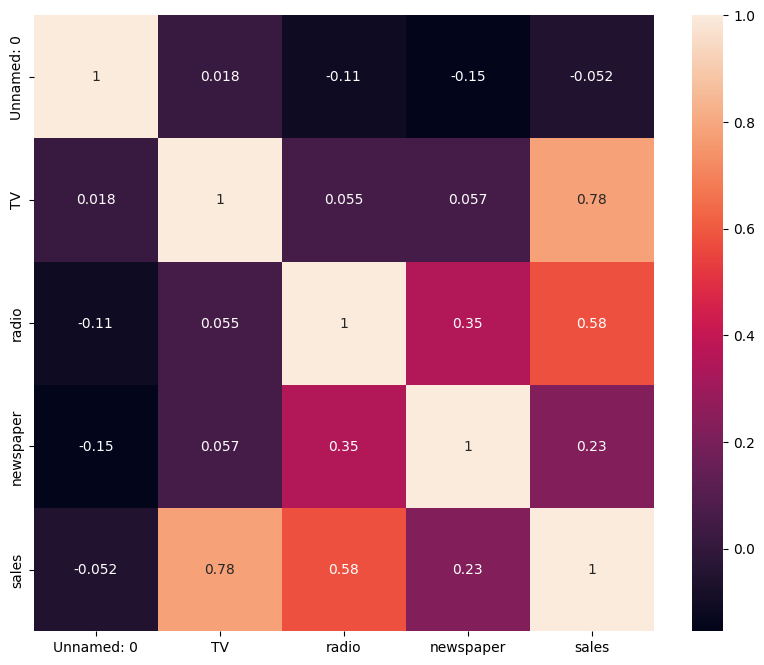

In [11]:
plt.subplots(figsize=(10, 8))
sns.heatmap(data_correlation, annot=True)
plt.show()

### Linear Regression Function
Creating a function for Linear Regression Model fit on the data

In [12]:
def Linear_Regression(x_train, y_train):
    print("Linear Regression: ")
    linear_regression = LinearRegression()
    linear_regression.fit(x_train, y_train)
    return linear_regression

### Lasso Regression Function
Creating a function for Lasso Regression Model fit on the data

In [13]:
def Lasso_Regression(x_train, y_train):
    print("Lasso Regression: ")
    lasso_regression = Lasso(alpha=0.8, max_iter=10000)
    lasso_regression.fit(x_train, y_train)
    return lasso_regression

### Ridge Regression Function
Creating a function for Ridge Regression Model fit on the data

In [14]:
def Ridge_Regression(x_train, y_train):
    print("Ridge Regression: ")
    ridge_regression = Ridge(alpha=0.9)
    ridge_regression.fit(x_train, y_train)
    return ridge_regression

### Sochastic Gradient Descent Regression

Creating a function for Sochastic Gradient Descent Regression Model fit on the data

In [15]:
def SGD_Regressor(x_train, y_train):
    print("SGD Regression: ")
    sgd_regression = SGDRegressor(max_iter=2000)
    sgd_regression.fit(x_train, y_train)
    return sgd_regression

### Multilayer Preceptron Regresson

Creating a function for MLP Regressor Neural Network to fit the data. 3 Hidden layers, with 13 neurons each.

In [16]:
def MLP_Regressor(x_train, y_train):
    print("MLP Regressor: ")
    mlp_regressor = MLPRegressor(activation='relu', hidden_layer_sizes=(13,13,13), solver='lbfgs', verbose = True, max_iter= 20000)
    mlp_regressor.fit(x_train, y_train)
    return mlp_regressor

### Build and Train Model Function
Creating a Function for building, training and evaluating the model by using the train test split method where X is all variables but the median value and Y is target name = sales. The function preprocesses the data using standard scaler, trains the model ans print out the r2 score for accuracy, with the predicted values vs actual values.

In [17]:
def build_and_train_model(data, target_name, reg_fn):
    X = data.drop(target_name, axis=1)
    Y = data[target_name]
    x_train, x_test, y_train, y_test = train_test_split(X, Y, shuffle=True, test_size=0.2)

    scaler = StandardScaler()
    scaler.fit(x_train)

    x_train = scaler.transform(x_train)

    x_test = scaler.transform(x_test)

    model = reg_fn(x_train, y_train)
    score = model.score(x_train, y_train)
    print("Training score: ", score)

    y_pred = model.predict(x_test)
    r_score = r2_score(y_test, y_pred)
    print("Testing Score : ", r_score)

    df_y = pd.DataFrame({'y_test' : y_test, 'y_pred' : y_pred})
    print(df_y.sample(10))
    plt.figure(figsize=(10, 8))

    plt.plot(y_pred, label='Predicted')
    plt.plot(y_test.values, label='Actual')
    plt.ylabel("medv of home")
    plt.legend()
    plt.show()

    return{'model' : model,
            'x_train' : x_train, 'x_test' : x_test,
            'y_train' : y_train, 'y_test' : y_test,
            'y_pred' : y_pred, 'sample' : df_y.sample(10)
            }





### Linear Regression Model fit Results
Utilizing the build and train model function to predict and score the Linear Regression algorithm on the data. 3 inputs as needed: data file, value to predict(price), and the type of model below. Results in order Training score, Testing/r2 score to predict accuracy, and the Y_test: actual values and Y_pred = predicted values.

Linear Regression: 
Training score:  0.8918552706718237
Testing Score :  0.9145554476755989
     y_test     y_pred
58     23.8  21.863000
72      8.8  10.368254
60      8.1   5.818283
151    11.6   9.974564
196     9.7   8.127386
168    17.1  17.097815
133    19.6  19.196371
44      8.5   8.912193
138     9.6   9.727247
136     9.5  11.394013


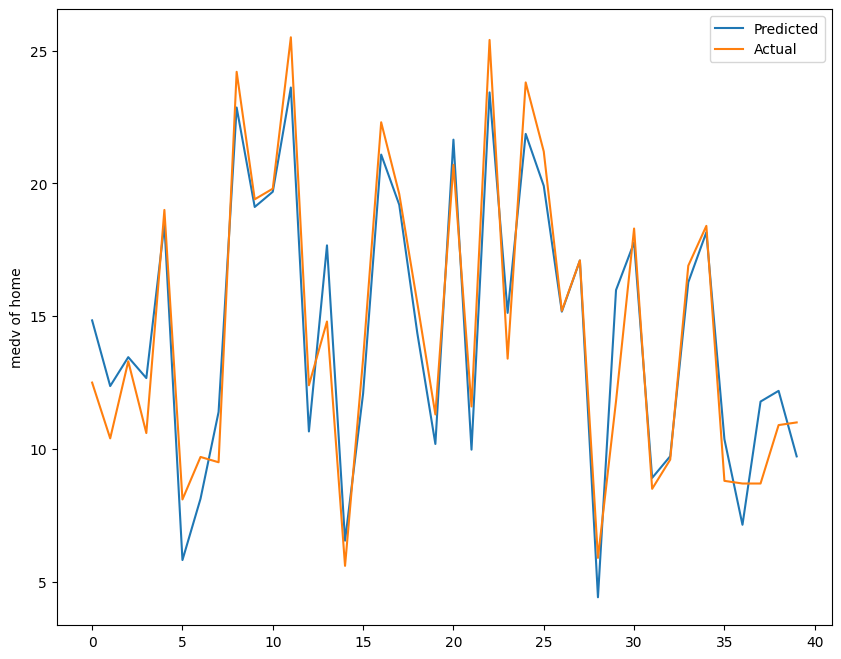

In [18]:
Linear_regression = build_and_train_model(data, "sales", Linear_Regression)

### Lasso Regression Model fit results

Utilizing the build and train model function to predict and score the Lasso Regression algorithm on the data. 3 inputs as needed: data file, value to predict(price), and the type of model below. Results in order Training score, Testing/r2 score to predict accuracy, and the Y_test: actual values and Y_pred = predicted values.

Lasso Regression: 
Training score:  0.8528794625113184
Testing Score :  0.8636220648318705
     y_test     y_pred
177    11.7  12.788440
87     16.0  15.035209
194    17.3  15.813974
188    15.9  17.959036
171    14.5  14.362497
140    10.9  10.417442
149    10.1  10.543084
159    12.9  12.792570
75      8.7  11.944207
91      7.3   6.624010


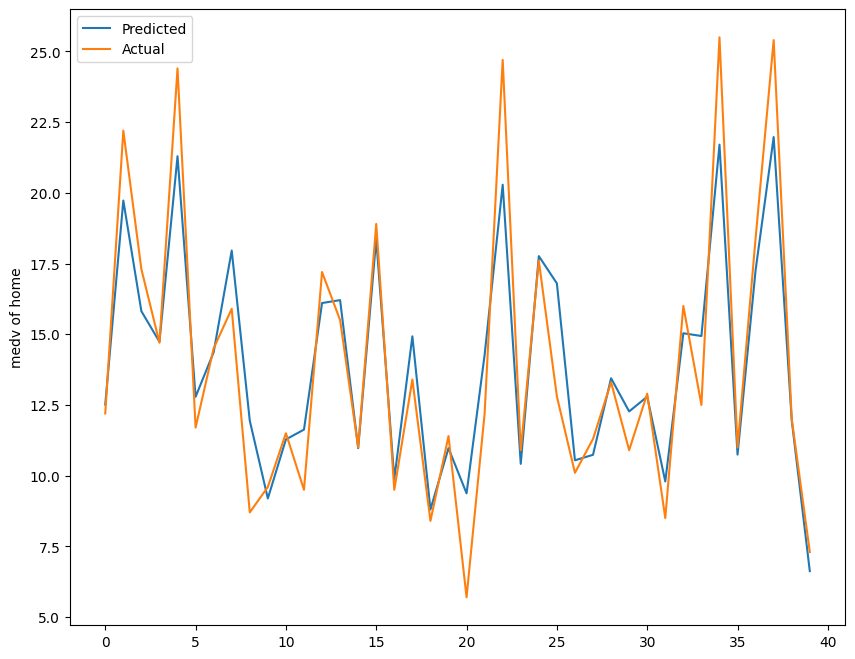

In [19]:
Lasso_regression = build_and_train_model(data, "sales", Lasso_Regression)

### Ridge Regression Model fit results

Utilizing the build and train model function to predict and score the Ridge Regression algorithm on the data. 3 inputs as needed: data file, value to predict(price), and the type of model below. Results in order Training score, Testing/r2 score to predict accuracy, and the Y_test: actual values and Y_pred = predicted values.

Ridge Regression: 
Training score:  0.8892703043177093
Testing Score :  0.9238040490032069
     y_test     y_pred
50     11.4  12.566388
72      8.8  10.427726
15     22.4  20.750943
6      11.8  11.794980
129     9.7   7.947224
65      9.3   7.862786
177    11.7  12.063979
59     18.4  17.973162
89     16.7  16.914544
69     22.3  20.949033


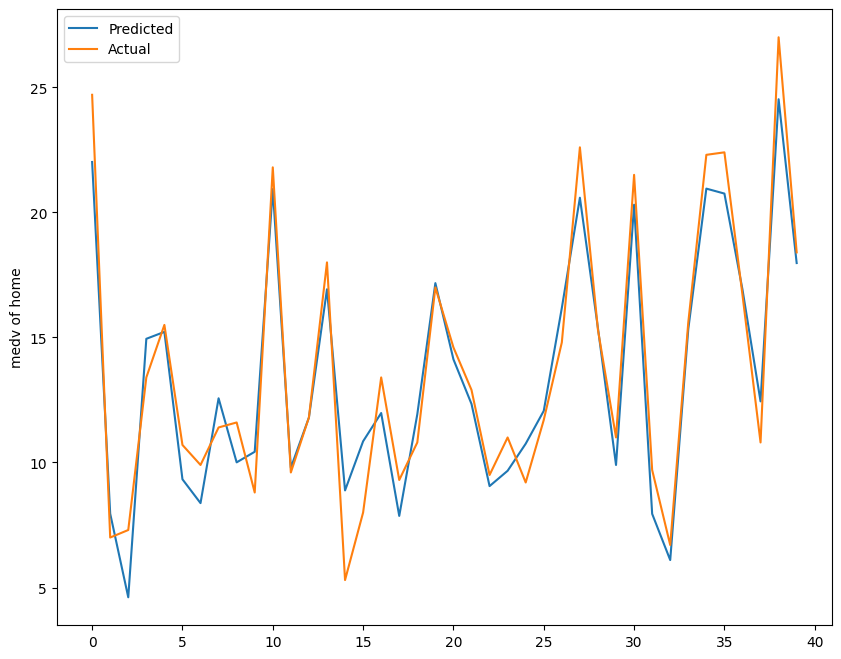

In [20]:
Ridge_regression = build_and_train_model(data, "sales", Ridge_Regression)

### Sochastic Gradient Descent Regression Model fit results

Utilizing the build and train model function to predict and score the Sochastic Gradient Descent Regression algorithm on the data. 3 inputs as needed: data file, value to predict(price), and the type of model below. Results in order Training score, Testing/r2 score to predict accuracy, and the Y_test: actual values and Y_pred = predicted values.

SGD Regression: 
Training score:  0.897618083281813
Testing Score :  0.8922923594955524
     y_test     y_pred
115    12.6  13.076499
108     5.3   3.648569
61     24.2  22.946693
86     12.0  11.562005
168    17.1  17.342655
164    11.9  11.010737
118    15.9  15.832994
124    19.7  19.658781
126     6.6  10.755933
104    20.7  20.150905


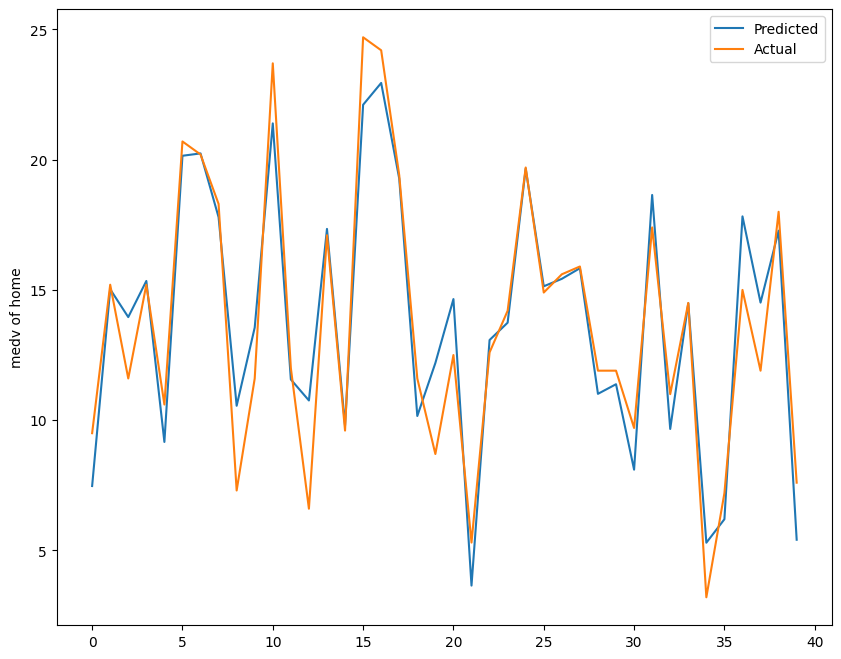

In [21]:
SGD_regression = build_and_train_model(data, "sales", SGD_Regressor)

### Multilayer Preceptron Regression Neural Network model fit results

Utilizing the build and train model function to predict and score the Multilayer Preceptron Regression Neural Network algorithm on the data. 3 inputs as needed: data file, value to predict(price), and the type of model below. Results in order Training score, Testing/r2 score to predict accuracy, and the Y_test: actual values and Y_pred = predicted values.

MLP Regressor: 
Training score:  0.999340351418374
Testing Score :  0.9466860708118325
     y_test     y_pred
62     15.7  16.088493
108     5.3   6.280224
192     5.9   6.648460
92     19.4  19.894632
181    12.2  12.132376
154    15.6  15.739121
33     17.4  15.976201
124    19.7  20.203600
27     15.9  15.684085
25     12.0  12.109476


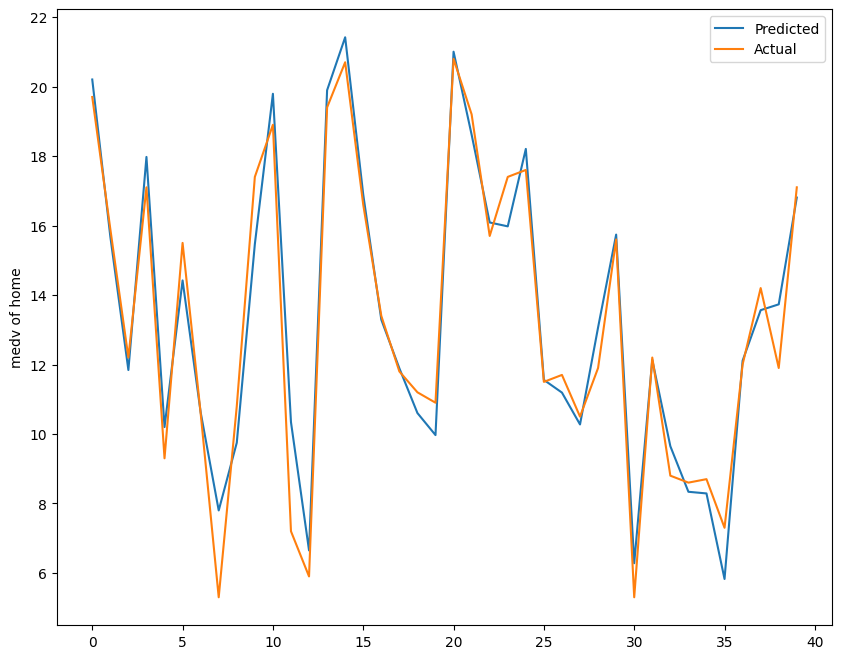

In [22]:
MLP_Regression = build_and_train_model(data, "sales", MLP_Regressor)